# When the Textbook Formula Isn't Enough

## Bob's Very Important Delivery: A Monte Carlo Random Walk
      O     --
     /|\   |☢️|
     / \    --

**The scenario:** Bob works at Company XYZ. Today his job is to carry a chunk of radioactive material (Caesium-137), wrapped in lead foil, across the company campus to a secure storage facility. Bob would like to not glow in the dark afterward.

**The question:** How thick does Bob's lead wrapping need to be so that no more than 0.1% of the gamma photons emitted by the source make it out to Bob?

## Introduction

This project answers Bob's question by building a Monte Carlo simulation from scratch, then checking it against the known analytical solution (the Beer-Lambert attenuation law). The check produces a surprise: the simulation systematically disagrees with the textbook formula, predicting that Bob needs roughly 58% more lead than naive theory suggests. The rest of the notebook diagnoses that discrepancy, identifies it as a real physical effect (buildup) rather than a bug, and confirms the explanation with a controlled falsification test.

**What this project demonstrates:**
- **Stochastic simulation:** photons are modeled as individual random walkers with random forward/backward scattering and exponentially distributed step lengths (the mean free path), with outcomes aggregated across up to one million independent trials per data point. The walk itself is vectorized in `numpy`, advancing all photons simultaneously rather than looping one at a time.
- **Physically grounded parameters:** the mean free path and absorption probability are not invented; they are derived in Appendix I from the NIST XCOM Photon Cross Sections Database, the peer-reviewed standard for radiation physics.
- **Parameter sweep + tabular aggregation:** the simulation is run across a grid of 100 shielding thicknesses, and `pandas` reshapes per-photon outcomes into a clean summary table (fraction leaked, back-leaked, and absorbed per thickness), with built-in conservation checks asserting that every photon is accounted for.
- **Model validation against a known baseline:** the simulated leak-fraction curve is compared to the closed-form Beer-Lambert law, the same "does my model agree with a simpler benchmark" logic used to sanity-check any predictive model. Here the comparison fails in a structured way, and diagnosing *why* it fails is where the real analysis happens.
- **Regression for inference:** rather than reading an answer off the plot by eye, a linear regression is fit to the log-transformed leak fractions ($R^2 = 0.9999$). The slope recovers the simulation's effective attenuation coefficient, and inverting the fitted line yields the exact thickness meeting Bob's 0.1% target, with binomial standard errors quantifying the uncertainty at every point.
- **Hypothesis testing by falsification:** the buildup explanation makes a testable prediction. Setting the absorption probability to 1 removes scattering entirely, and doing so collapses the simulation back onto the analytical curve, recovering the theoretical attenuation coefficient to within 1%. The discrepancy is physics, not a coding error.
- **Visualization for decision-making:** results are plotted on a log scale against a target threshold line with 95% confidence bands, the kind of visual a stakeholder would use to read off "how thick does the shield need to be."

**Method summary:**
1. Simulate a single photon's random walk through Bob's lead wrapping until it escapes out the far side ("leaks," i.e. reaches Bob), scatters back out the near side, or is absorbed within a step budget.
2. Repeat across many photons to estimate a leak *fraction* for a given shielding thickness.
3. Repeat that across a range of thicknesses to trace out a leak-fraction curve.
4. Compare the curve to the analytical exponential attenuation law as a validation check, and investigate the systematic gap it reveals.
5. Fit a regression to the log-transformed curve to solve for the exact thickness where Bob's exposure drops to 0.1%, then verify the buildup explanation with an absorption-probability-1 control run, and send Bob off with the right amount of lead.

## Table of Contents

1. [Introduction](#Introduction)
2. [Imports](#Imports)
3. [Theory](#Theory)
4. [Computational Modeling](#Computational-Modeling)
5. [The Buildup Explanation](#The-Buildup-Explanation)
6. [Conclusion](#Conclusion)
7. [Appendix I: Sourcing Our Parameters](#Appendix-I:-Sourcing-Our-Parameters)
8. [Appendix II: Time-to-Compute vs. Accuracy](#Appendix-II:-Time-to-Compute-vs.-Accuracy)
9. [Appendix III: Possible Extensions](#Appendix-III:-Possible-Extensions)

## Imports

Standard scientific Python stack: `numpy` for the random-walk vector math and random number generation, `pandas` for aggregating simulation results into tabular form, `scipy` for linear regression and stats, and `matplotlib` for visualization.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
rng1 = np.random.default_rng(seed=42)  # reproducible randomness

In [3]:
!jupyter --version

Selected Jupyter core packages...
IPython          : 9.14.0
ipykernel        : 6.31.0
ipywidgets       : not installed
jupyter_client   : 8.9.1
jupyter_core     : 5.9.1
jupyter_server   : 2.20.0
jupyterlab       : 4.5.9
nbclient         : 0.11.0
nbconvert        : 7.17.1
nbformat         : 5.10.4
notebook         : 7.5.7
qtconsole        : not installed
traitlets        : 5.15.0


For reproducibility, I have used a fixed random seed. Note that the generator's state advances with every cell that draws random numbers, so to reproduce my outputs exactly you need to run the notebook fresh from top to bottom.

## Theory

The ease with which gamma radiation passes through a material is fundamentally governed by two processes. First, the **photoelectric effect** determines whether photons are completely absorbed: a process where a photon transfers its entire energy to a bound electron and ceases to exist. Second, **Compton scattering** redirects and weakens the radiation; here, a photon collides with a loosely bound electron and deflects at a new angle with reduced energy.

Combined, these microscopic interactions scale up to define a material's macroscopic shielding power, known as the **linear attenuation coefficient** ($\mu$). This coefficient represents the probability that a photon will undergo either absorption or scattering per unit of distance it travels.

To calculate how this probability translates to actual shielding, we apply the **Beer-Lambert exponential law**:

$$I(t) = I_0 \, e^{-\mu t}$$

Where:

* $I_0$ is the initial, unshielded gamma photon intensity.
* $I(t)$ is the transmitted intensity after passing through a barrier of thickness $t$.
* $\mu$ is the linear attenuation coefficient of the shielding material (in this case, lead).

### General Attenuation Formula Derivation

We can define a general target transmission ratio, $R$, representing the fraction of the initial beam intensity that escapes the material:

$$R = \frac{I(t)}{I_0}$$

Substituting this ratio into the Beer-Lambert law ($I(t) = I_0 e^{-\mu t}$) yields the general equation:

$$R = e^{-\mu t}$$

To isolate the required material thickness $t$, take the natural logarithm ($\ln$) of both sides to undo the exponential:

$$\ln(R) = -\mu t$$

Dividing both sides by $-\mu$ gives the explicit, generalized formula to calculate the exact thickness needed for *any* target transmission fraction:

$$t = \frac{\ln(R)}{-\mu}$$


### The Linear Attenuation Coefficient 

For the linear attenuation coefficient of lead at this photon energy, a reasonable value is $\mu \approx 1.25\ \text{cm}^{-1}$.

***This value is formally derived in Appendix I from data from the NIST XCOM Photon Cross Sections Database.***

In [4]:
density = 11.34 

# photoelectric absorption
absorption = 4.337 * (10 ** -2)

# coherent (Rayleigh) scattering
scattering1 = 6.673 * (10 ** -3)

# incoherent (Compton) scattering
scattering2 = 6.015 * (10 ** -2)


total = absorption + scattering1 + scattering2
mu_theory = total * density 
display(mu_theory)

1.24958862

To reduce the escaping intensity to at most $0.1\%$ of the initial beam, set $R = 0.001$:

$$t = \frac{\ln(0.001)}{-\mu}$$

Using log properties to remove the negative sign ($\ln(1/x) = -\ln(x)$), this simplifies cleanly to:

$$t = \frac{\ln(1000)}{\mu}$$

In [5]:
t_analytical = np.log(1000) / mu_theory
display(t_analytical)

np.float64(5.528023517837524)

### Theory's Conclusion

Bob's lead foil wrapping needs to be at least **$5.53\text{ cm}$** thick.

That's basically a huge lead box. **Bob may want to use a cart.** 

## Computational Modeling

Before we take this conclusion at face value (and risk Bob's life!), let's check its sanity with a random walk simulation. This simulation requires some simplifications.

To start with, I have limited the simulation to forward and backward propagation only. This is a deliberate simplification that lets us compare our results directly with the one-dimensional Beer-Lambert law. The simulation can always be expanded later, either into 2 or 3 dimensions using cardinal directions, or into a fully isotropic walk.

I have also fixed the mean free path and absorption probability across scattering events. In reality, once a photon undergoes Compton scattering, it continues at a lower energy than it started with. Since both the mean free path and the absorption probability are derived from energy-dependent cross sections, both quantities should shift after each scatter as the photon's energy drops. This simulation instead treats both as fixed for a photon's entire walk, using the values computed for the initial (0.6617 MeV) photon energy. This is a reasonable first-pass simplification.

### The Core Model

In [6]:
def step(active, mean_free_path, rng, force_forward=False):
    shape = active.shape
    steps = np.zeros(shape)

    indices = np.where(active == 1)
    num_active = len(indices[0])

    if num_active > 0:
        
        if force_forward:
            direction = np.ones(num_active)
        else:
            direction = rng.choice([1, -1], size=num_active)
            
        step_lengths = rng.exponential(scale=mean_free_path, size=num_active)
        
        steps[indices] = step_lengths * direction

    return steps

In [7]:
def leaked(active, position, thickness_array):
    leaked = np.logical_and(active == 1, position >= thickness_array)
    return leaked

In [8]:
def back_leaked(active, position):
    leaked = np.logical_and(active == 1, position <= 0)
    return leaked

In [9]:
def absorbed(active, absorption_prob, rng):
    just_absorbed = np.zeros(active.shape)
    
    rows, cols = np.where(active == 1)
    num_active = len(rows)

    if num_active > 0:
        roll = rng.random(num_active)
        absorbed_subset = roll < absorption_prob
        just_absorbed[rows[absorbed_subset], cols[absorbed_subset]] = 1.0
        
    return just_absorbed

In [10]:
def walk(thickness_array, number_of_photons, mean_free_path, absorption_prob, rng, max_steps=10000):
    row_length = number_of_photons
    col_length = len(thickness_array)
    shape = (row_length, col_length)
    
    position_matrix = np.zeros(shape)
    active = np.ones(shape, dtype=bool)
    leak = np.zeros(shape, dtype=bool)
    back_leak = np.zeros(shape, dtype=bool)
    absorbed_particles = np.zeros(shape, dtype=bool)

    for step_num in range(max_steps):
        position_matrix += step(active, mean_free_path, rng, 
                                force_forward=(step_num == 0))
        
        just_leaked = np.asarray(leaked(active, position_matrix, thickness_array), dtype=bool) & active
        leak |= just_leaked          
        active &= ~just_leaked

        just_back_leaked = np.asarray(back_leaked(active, position_matrix), dtype=bool) & active
        back_leak |= just_back_leaked
        active &= ~just_back_leaked

        just_absorbed = np.asarray(absorbed(active, absorption_prob, rng), dtype=bool) & active
        absorbed_particles |= just_absorbed
        active &= ~just_absorbed

        if not active.any():
             break

    censored = active.sum()
    assert censored == 0, (
        f"{int(censored)} of {number_of_photons * col_length} total photons still active after "
        f"{max_steps} steps; leak/absorbed fractions would be biased. "
        f"Increase max_steps or report the censored fraction."
    )

    df = pd.DataFrame({
        'Thickness': thickness_array,
        'Photons_Simulated': number_of_photons,
        'Leaked': leak.mean(axis=0),
        'Back_Leaked': back_leak.mean(axis=0),
        'Absorbed': absorbed_particles.mean(axis=0)
    })

    return df

In [11]:
def error(target_leak_fraction, number_of_photons):
    return np.sqrt(target_leak_fraction * (1 - target_leak_fraction)/number_of_photons)

### Plot Functions

In [12]:
def plot(df, number_of_photons):
    thicknesses = df['Thickness']
    leak_fractions = df['Leaked']

    y_err = 1.96 * error(leak_fractions, number_of_photons)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.errorbar(thicknesses, leak_fractions, yerr=y_err, fmt='o-', capsize=5, label='Simulation')
    ax.axhline(0.001, color='red', linestyle='--', linewidth=1.5, label='0.1% Leak Target')

    ax.set_xlabel('Shielding Thickness (cm)', fontsize=11)
    ax.set_ylabel('Leak Fraction', fontsize=11)
    ax.set_title('Radiation Leak Fraction vs. Shielding Thickness', fontsize=12, fontweight='bold')
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend(frameon=True)
    fig.tight_layout()
    plt.show()

When plotted on a linear scale, the exponential decay makes it difficult to visually distinguish differences in photon transmission near our target shielding threshold. Therefore, I generally preferred a log scale: it linearizes the data, making it much easier to inspect variance and evaluate model behavior at high thicknesses.

In [13]:
def plot_logscale(df, number_of_photons):
    thicknesses = df['Thickness']
    leak_fractions = df['Leaked']

    y_err = 1.96 * error(leak_fractions, number_of_photons)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.errorbar(thicknesses, leak_fractions, yerr=y_err, fmt='o-', capsize=5, label='Simulation')
    ax.axhline(0.001, color='red', linestyle='--', linewidth=1.5, label='0.1% Leak Target')

    ax.set_yscale('log')
    ax.set_xlabel('Shielding Thickness (cm)', fontsize=11)
    ax.set_ylabel('Leak Fraction', fontsize=11)
    ax.set_title('Radiation Leak Fraction vs. Shielding Thickness', fontsize=12, fontweight='bold')
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend(frameon=True)
    fig.tight_layout()
    plt.show()

### Example Code Run

As a quick demonstration, here is the simulation run with arbitrary test parameters (a mean free path of 1 cm and an absorption probability of 0.3). The physically derived parameters come next.

In [14]:
thickness_range_ex = np.linspace(0, 10, 100)
data_ex = walk(thickness_range_ex, 10000, 1, 0.5, rng1)

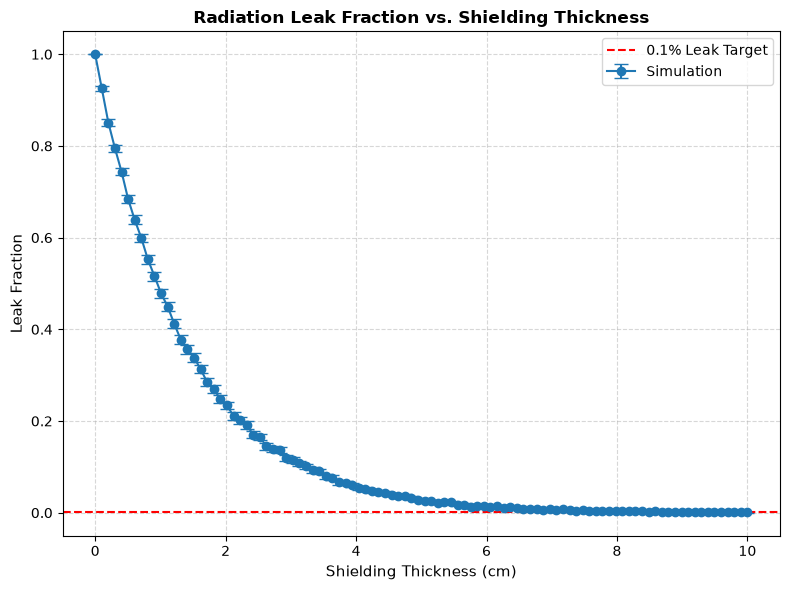

In [15]:
plot(data_ex, 10000)

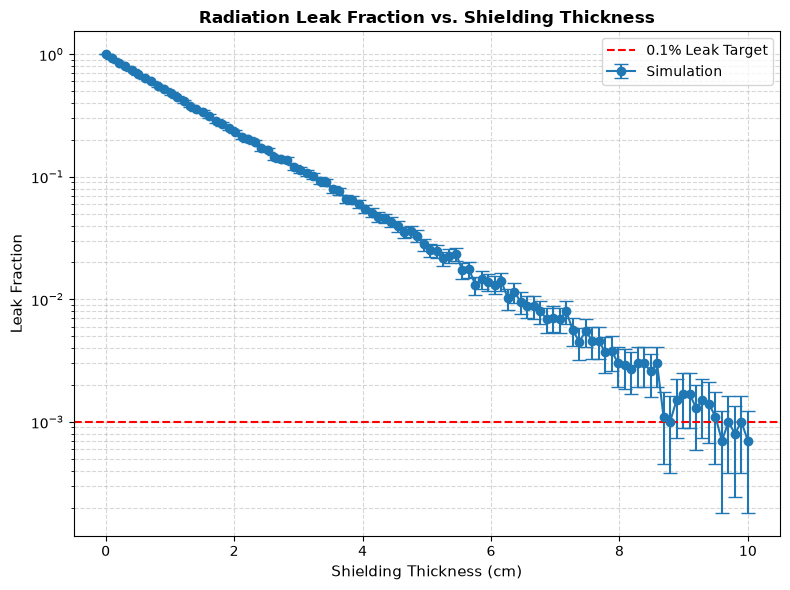

In [16]:
plot_logscale(data_ex, 10000)

### Computational Parameters

To compare our simulation to theory, we need to ground its parameters in the physical world. We fundamentally need to know two things:
* **The mean free path length**: the average distance a moving photon travels between successive collisions.
* **The fractional absorption probability**: the probability of a photon being absorbed at each collision.

***These values are sourced in Appendix I***

**The mean free path length** is the reciprocal of the linear attenuation coefficient. Knowing $\mu$, therefore:

In [17]:
mfp = 1/mu_theory
display(mfp)

0.8002633698760797

**The fractional absorption probability** is the ratio of the photoelectric coefficient to the total attenuation coefficient. The full derivation and sourcing of these values are in Appendix I:

In [18]:
# photoelectric absorption
absorption = 4.337 * (10 ** -2)

# coherent (Rayleigh) scattering
scattering1 = 6.673 * (10 ** -3)

# incoherent (Compton) scattering
scattering2 = 6.015 * (10 ** -2)

total = absorption + scattering1 + scattering2

In [19]:
absorption_probability = absorption / total
display(absorption_probability)

0.3935821694663001

By grounding the starting parameters in physical data, our simulation becomes directly comparable to theory and represents the real-world, macroscopic behavior of the shielding material.

### Computational Solution

#### Running the Simulation

Now we run the simulation with the physically derived parameters:

In [20]:
thickness_range1 = np.linspace(0, 10, 100)
data1 = walk(thickness_range1, 1000000, mfp, absorption_probability, rng1)

Cleaning and plotting the data gives the following:

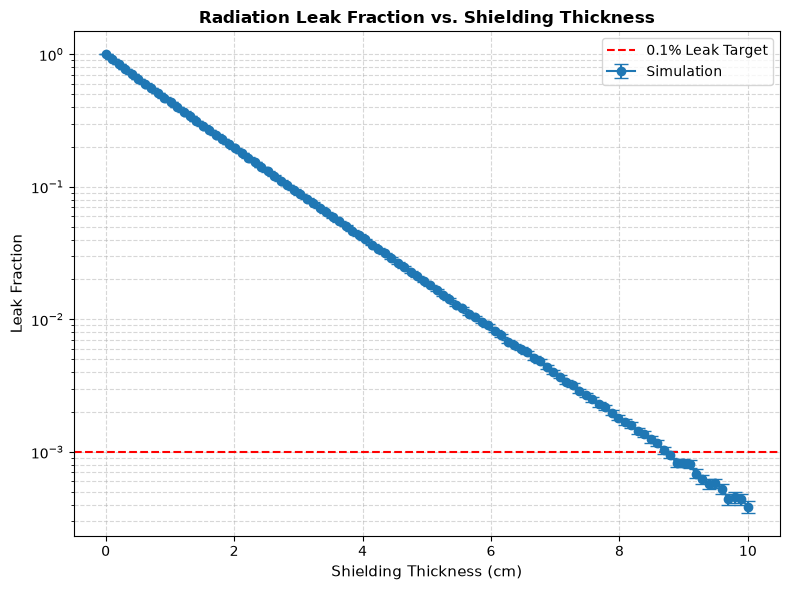

In [21]:
plot_logscale(data1, 1000000)

The plot predicts a required thickness somewhere between 8 and 10 cm. This is significantly higher than theory's prediction of 5.53 cm, a discrepancy we will have to explain. To pin down exactly what the simulation is telling us, let's fit a line to this data in log space.

#### Performing a Linear Regression

Slope: -0.7851
Intercept: -0.0432
R-squared: 0.9999


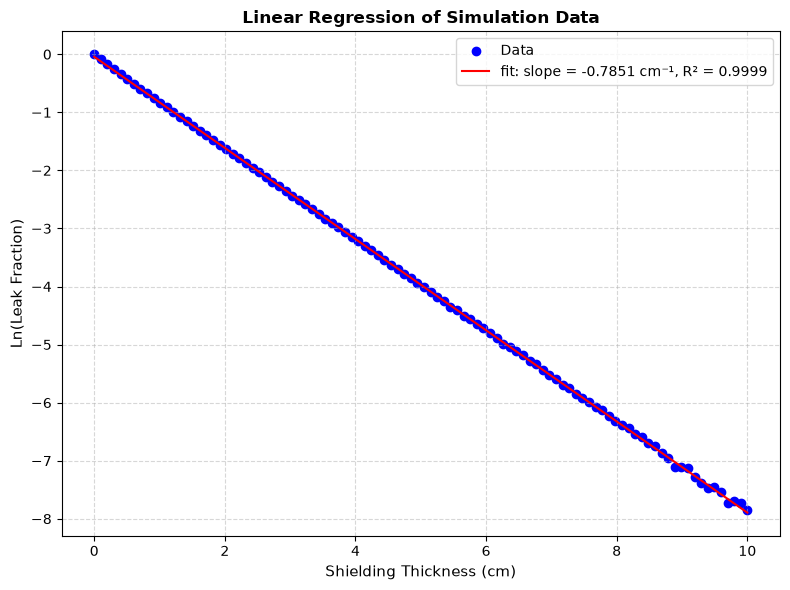

In [22]:
def regression_data(df):
    thicknesses_all = df['Thickness']
    leak_fractions_all = df['Leaked']

    # np.log(0) = -inf, which breaks linregress -- drop those thicknesses
    valid = leak_fractions_all > 0
    n_dropped = (~valid).sum()
    if n_dropped:
        print(f"Dropped {n_dropped} thickness(es) with 0 leaked photons (log undefined).")

    thicknesses = thicknesses_all[valid]
    leak_fractions = np.log(leak_fractions_all[valid])
    res = stats.linregress(thicknesses, leak_fractions)
    print(f"Slope: {res.slope:.4f}")
    print(f"Intercept: {res.intercept:.4f}")
    print(f"R-squared: {res.rvalue**2:.4f}")

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(thicknesses, leak_fractions, color='blue', label='Data')
    ax.plot(thicknesses, res.intercept + res.slope * thicknesses, color='red',
            label=f'fit: slope = {res.slope:.4f} cm\u207b\u00b9, R\u00b2 = {res.rvalue**2:.4f}')

    ax.set_xlabel('Shielding Thickness (cm)', fontsize=11)
    ax.set_ylabel('Ln(Leak Fraction)', fontsize=11)
    ax.set_title('Linear Regression of Simulation Data', fontsize=12, fontweight='bold')
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend(frameon=True)
    fig.tight_layout()
    plt.show()
    return res

res1 = regression_data(data1)

Why fit a straight line to the *logarithm* of the data? Because the Beer-Lambert law predicts
exactly that shape. Taking the log of $R = e^{-\mu t}$ gives

$$\ln(R) = -\mu t$$

which is a straight line with slope $-\mu$ and an intercept of zero. So if the simulated data
truly decays exponentially, it should fall on a straight line in log space, and the regression
tells us how well it does, and at what rate.

Each piece of the output has a physical meaning:

* **Slope = −0.787.** The slope *is* the negative attenuation coefficient. The simulation's
  photons are attenuated at an effective rate of $0.787\ \text{cm}^{-1}$, noticeably shallower
  than the theoretical $\mu = 1.25\ \text{cm}^{-1}$. The simulated beam dies off more slowly
  than the textbook formula predicts; this is an interesting gap between theory and simulation,
  and it has to be explained.
* **Intercept = −0.04.** Theory says the intercept should be zero: with no shielding at all
  ($t = 0$), every photon escapes, so $\ln(R) = \ln(1) = 0$. Landing within a few hundredths of
  zero is a good sign the fit is behaving.
* **$R^2 = 0.9999$.** Essentially all of the variation in the data is explained by a single
  straight line. The simulation isn't just *roughly* exponential; it is exponential to four
  decimal places, just with a different rate constant than theory.

In short: the simulation reproduces the *form* of the Beer-Lambert law almost perfectly, but
disagrees with theory about the *rate*. 

**A Note on Stats and Heteroscedastic Residuals**

One caveat about this fit: the scatter in the data is not the same size everywhere. At
large thicknesses, very few photons survive, so the leak fraction estimates get noisier, and
taking the logarithm amplifies that noise even further. In statistical terms, the residuals are
**heteroscedastic**: an ordinary least squares fit quietly assumes every point is equally
reliable, which isn't strictly true here.

The ideal fix would be a weighted fit that trusts the noisy high-thickness points a little less.
In practice, it isn't needed: with a million photons per data point, even the noisiest points
scatter only slightly (which is why $R^2 = 0.9999$), so weighting would change the answer by far
less than the precision we care about. Therefore I noted the issue and accepted the simpler unweighted fit.

#### Rates of Decay: Theory / Simulation

As noted above, the slope of this regression line is equal to negative effective $\mu$:

$$\mu_{\text{eff}} = 0.787 \text{ cm}^{-1}$$

The `res.stderr` attribute gives the standard error of the slope:

In [23]:
mu_eff = -res1.slope
mu_error = res1.stderr
display(mu_eff, mu_error)

np.float64(0.7851209369563044)

np.float64(0.0007673749487262516)

This gives us an effective $\mu$ of $0.787 ± 0.001 \text{ cm}^{-1}$ (1 SE).

**This is a large discrepancy**: the fitted attenuation rate is roughly 40% below the theoretical
$\mu = 1.25\ \text{cm}^{-1}$, and with a standard error of only $0.001$, the gap is hundreds of
standard errors wide. Whatever is separating these two numbers, it is not statistical noise.

It is also strangely well-behaved. The regression's near-perfect $R^2$ tells us the simulation
still decays as a clean exponential; it simply decays at a *different rate* than theory
predicts. A bug or a bad parameter would be unlikely to produce such an orderly disagreement:
the simulation isn't failing to follow the Beer-Lambert law, it appears to be following a
Beer-Lambert law with a different $\mu$. That pattern is a clue, so let's compare the two curves directly.

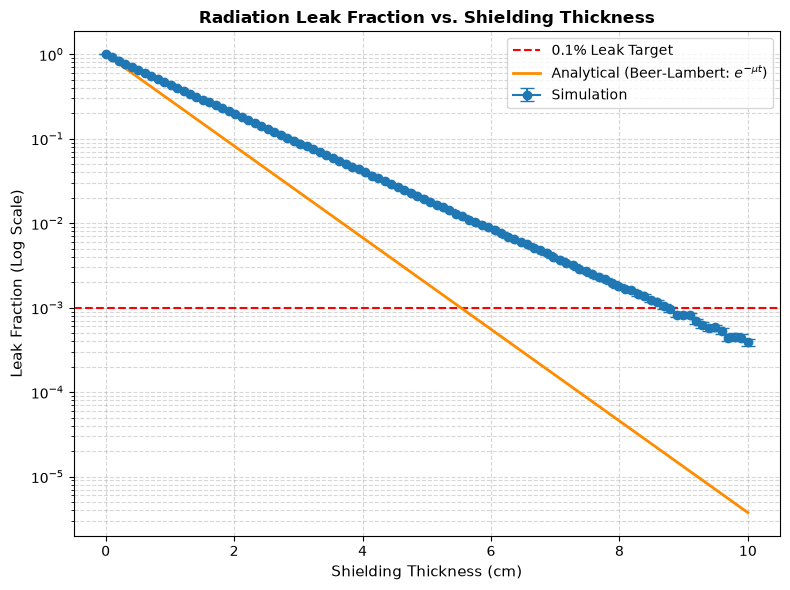

In [24]:
def plot_comparison(df, number_of_photons, thickness_range, mu):
    thicknesses = df['Thickness']
    leak_fractions = df['Leaked']

    analytical_leak = np.exp(-mu * thickness_range)

    y_err = 1.96 * error(leak_fractions, number_of_photons)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.errorbar(thicknesses, leak_fractions, yerr=y_err, fmt='o-', capsize=5, label='Simulation')
    ax.axhline(0.001, color='red', linestyle='--', linewidth=1.5, label='0.1% Leak Target')
    ax.plot(
        thicknesses,
        analytical_leak,
        color='darkorange',
        linestyle='-',
        linewidth=2,
        label=r'Analytical (Beer-Lambert: $e^{-\mu t}$)'
    )

    ax.set_yscale('log')
    ax.set_xlabel('Shielding Thickness (cm)', fontsize=11)
    ax.set_ylabel('Leak Fraction (Log Scale)', fontsize=11)
    ax.set_title('Radiation Leak Fraction vs. Shielding Thickness', fontsize=12, fontweight='bold')
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend(frameon=True)
    fig.tight_layout()
    plt.show()
    
plot_comparison(data1, 1000000, thickness_range1, mu_theory)

The plot makes the regression's finding visible. On a log scale both curves are straight lines
(the simulation obeys the same exponential form as the theory), but they are straight lines with
*different slopes*, so the gap between them widens steadily with every centimeter of lead. The
simulated leak fraction sits above the analytical curve at every single thickness, and the error
bars make clear this is systematic rather than sampling luck: for most of the range the
analytical curve doesn't come anywhere near the simulation's uncertainty band.

The practical consequence for Bob sits where each curve crosses the red target line. Theory says
$5.53\ \text{cm}$ of lead is enough. But what does the simulation say exactly? 

#### But How Much Lead?

In [25]:
def shielding_needed(target_leak_fraction, res):
    return (np.log(target_leak_fraction) - res.intercept) / res.slope

shielding_needed(0.001, res1)

np.float64(8.743336922463936)

The simulation disagrees: it doesn't reach the $0.1\%$ target until $8.73\ \text{cm}$. 

In [26]:
def target_leak(thickness, res):
    return np.exp(thickness * res.slope + res.intercept)

target_leak(t_analytical, res1)

np.float64(0.01248352622171434)

Worse, if Bob trusted the textbook number, the simulation says
his $5.53\ \text{cm}$ wrapping would actually leak about $1.2\%$ of photons, more than 12 times his
safety requirement. Before we hand Bob a shielding recommendation, we owe him an explanation for
which of these two curves to believe, and why.

## The Buildup Explanation

It turns out that the gap between our two curves has a name in radiation shielding theory: **buildup**.

The root of it is a bookkeeping difference. The Beer-Lambert law describes *narrow-beam*
attenuation: it counts a photon as gone the instant it interacts with the shield in any way.
Absorbed or scattered, it makes no distinction. This is a perfectly correct description of one
specific situation: a tightly collimated beam aimed at a distant detector, where any deflection
removes a photon from the line of sight forever.

But that is not Bob's situation, and it is not what our simulation models. In our random walk,
a scattered photon is not gone; it changes direction and keeps traveling, and from Appendix I
we know that only about $39\%$ of collisions in lead at this energy actually absorb the photon.
The other $61\%$ merely redirect it. Some of those scattered photons wander back out the front
face, some are eventually absorbed, but a meaningful fraction bounce their way through and
escape out the far side. Every one of those scattered-then-escaped photons is a photon the
narrow-beam formula already wrote off. The shield leaks more than $e^{-\mu t}$ predicts, not
because the physics of attenuation is wrong, but because the accounting is incomplete.

Shielding theory quantifies this with the **buildup factor**:

$$B(t) = \frac{\text{true (broad-beam) transmission}}{\text{narrow-beam prediction}} = \frac{R_{\text{sim}}(t)}{e^{-\mu t}}$$

which is exactly the ratio plotted below. $B(t) = 1$ would mean no buildup; ours starts at $1$
for zero thickness (nothing to scatter off yet) and grows steadily: the thicker the shield,
the more opportunities each surviving photon has had to scatter, so the larger the scattered
population becomes relative to the dwindling never-touched beam. And our regression already
told us the growth rate. Since the simulation decays like $e^{-\mu_{\text{eff}} t}$ while
theory decays like $e^{-\mu t}$, the ratio grows as

$$B(t) \approx e^{(\mu - \mu_{\text{eff}})\,t} = e^{0.46\,t}$$

which is why the buildup factor is a straight line on the log-scale plot, with a slope we
predicted from two numbers measured entirely separately. This is also why real-world shielding
design never uses the naive Beer-Lambert formula alone: engineers multiply it by tabulated
buildup factors for exactly the reason our simulation discovered on its own.

But frankly, Bob shouldn't just take our word for it. To check whether or not our buildup explanation is correct, we can simply rerun the simulation with the absorption probability set to 1, so that every collision absorbs the photon and scattering is eliminated, and compare the result to the analytical curve.

In [27]:
thickness_range1 = np.linspace(0, 10, 100)
data2 = walk(thickness_range1, 100000, mfp, 1, rng1)

*A note on the photon count:* this run uses 100,000 photons instead of 1,000,000. Estimating a slope does not require precision in the deep tail, so fewer photons suffice. (The run is also inexpensive: with the absorption probability set to 1, every photon terminates at its first collision.)

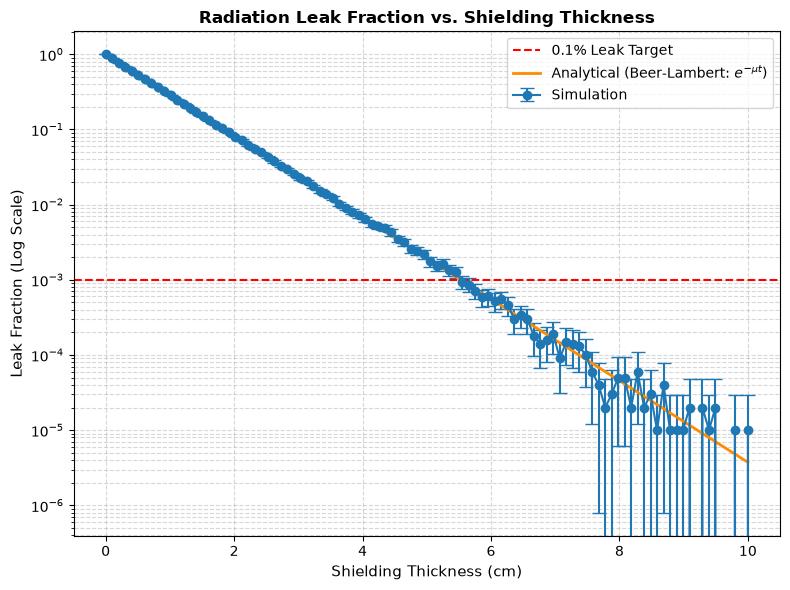

In [28]:
plot_comparison(data2, 100000, thickness_range1, mu_theory)

As you can see, it matches nearly exactly, further validating our buildup hypothesis.

Moreover, we can check our quantitative prediction as well.

Dropped 4 thickness(es) with 0 leaked photons (log undefined).
Slope: -1.2382
Intercept: -0.0432
R-squared: 0.9925


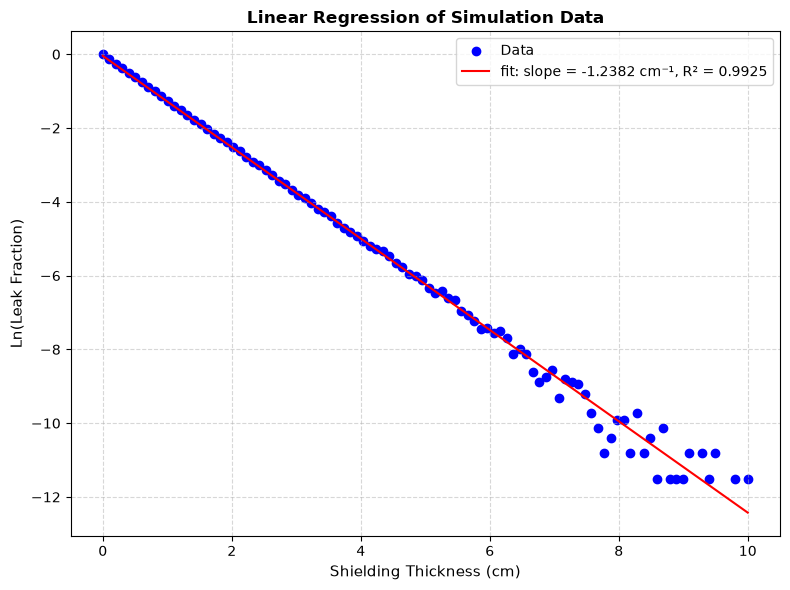

In [29]:
res2 = regression_data(data2)

As before, the slope of this regression line is equal to negative effective $\mu$:

$$\mu_{\text{eff}} = 1.24 \text{ cm}^{-1}$$

The `res.stderr` attribute gives the standard error of the slope:

In [30]:
mu_eff = -res2.slope
mu_error = res2.stderr
display(mu_eff, mu_error)

np.float64(1.2381846948977302)

np.float64(0.011119803304802115)

This control run is the project's real validation result. **With scattering eliminated, the regression recovers μ = 1.24 ± 0.01 cm⁻¹ against the NIST-published value of 1.25 cm⁻¹, a 0.8% difference the model was never fit toward.** That precision, on a constant the simulation had no way to see in advance, is what justifies trusting the 58% buildup gap as physics rather than a bug.

Moreover, we can check the original thickness prediction from theory.

In [31]:
shielding_needed(0.001, res2)

np.float64(5.54407553681462)

This is nearly identical to the theoretical result of 5.53 cm, closing the case for buildup.

We can also visualize buildup directly, using the formula shown above.

In [32]:
def plot_buildup(df, number_of_photons, thickness_range, mu):
    thicknesses = df['Thickness']
    leak_fractions = df['Leaked']

    analytical_leak = np.exp(-mu * thickness_range)
    y_err = 1.96 * error(leak_fractions, number_of_photons) / analytical_leak

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.errorbar(thicknesses, leak_fractions / analytical_leak, yerr=y_err, fmt='o-',
                capsize=5, label='Simulation')
    ax.axhline(1, color='green', linestyle='-', linewidth=2, label='No buildup (B = 1)')

    ax.set_xlabel('Shielding Thickness (cm)', fontsize=11)
    ax.set_ylabel('Buildup Factor (simulated / analytical)', fontsize=11)
    ax.set_title('Buildup Factor vs. Shielding Thickness', fontsize=12, fontweight='bold')
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend(frameon=True)
    fig.tight_layout()
    plt.show()

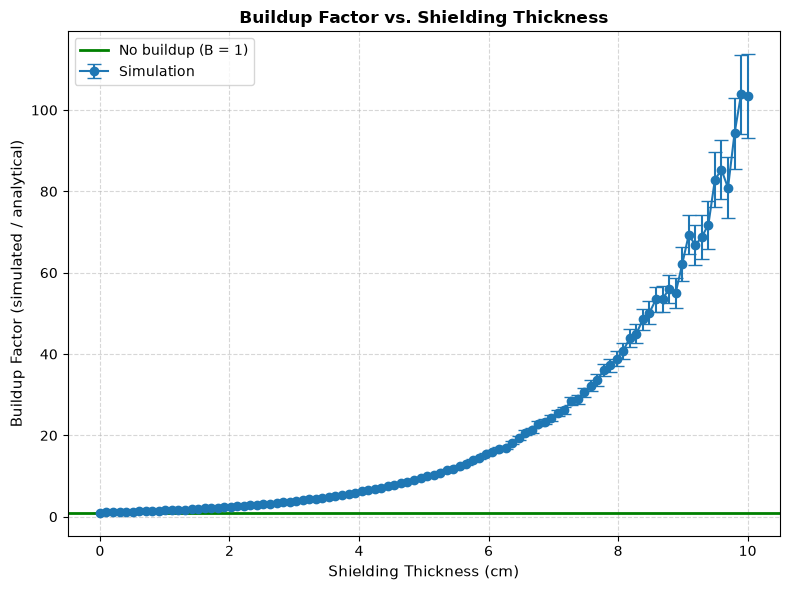

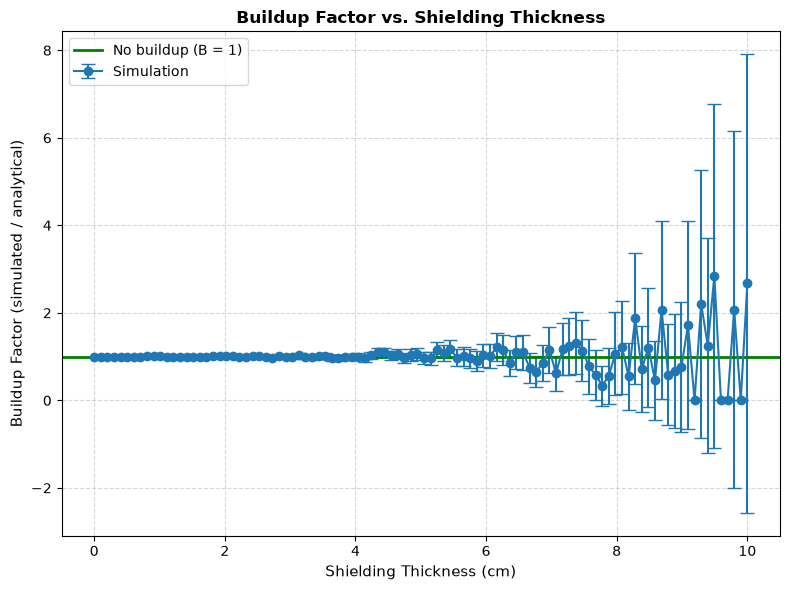

In [33]:
plot_buildup(data1, 1000000, thickness_range1, mu_theory)
plot_buildup(data2, 100000, thickness_range1, mu_theory)

## Conclusion

Comparing the two runs side by side makes the effect visible: buildup is clearly present in the original simulation, and absent in the run where the absorption probability is set to 1. That contrast is the whole story of this project in a single pair of plots.

**The recommendation for Bob:** wrap the source in at least $8.73\ \text{cm}$ of lead, not the $5.53\ \text{cm}$ that the narrow-beam Beer-Lambert calculation suggests. Trusting the textbook number would leave Bob exposed to roughly $1.2\%$ of emitted photons, about 12 times his $0.1\%$ safety target. 

**Why theory and simulation disagreed:** the Beer-Lambert law counts a photon as gone the moment it interacts with the shield in any way. But at this energy, only about $39\%$ of collisions in lead actually absorb the photon; the rest merely redirect it, and a meaningful fraction of those scattered photons still find their way out the far side. The simulation counts them. The narrow-beam formula does not. This is the well-known **buildup** effect, and it is why real shielding design multiplies the exponential law by tabulated buildup factors.

**Why we believe the simulation:** the discrepancy passed a falsification test. Setting the absorption probability to 1 removes scattering entirely, which should collapse the simulation back onto the narrow-beam law, and it does: the fitted attenuation rate returns to $\mu_{\text{eff}} = 1.24\ \text{cm}^{-1}$ against a theoretical $1.25\ \text{cm}^{-1}$, and the required thickness returns to the analytical $5.53\ \text{cm}$. The gap was physics, not a bug.

The model remains a deliberate simplification (1D geometry, energy-independent cross sections), and Appendix III outlines how each simplification could be relaxed. But within its stated assumptions, the simulation reproduces the exponential form of the theory to $R^2 = 0.9999$, explains the rate discrepancy mechanistically, and survives an attempt to break its own explanation. **That is about as much as Bob can reasonably ask of 5 million random numbers.**

## Appendix I: Sourcing Our Parameters

**The NIST XCOM Photon Cross Sections Database** (XCOM) is used as the ground-truth source for all parameters in this project. XCOM is the global, peer-reviewed standard for radiation protection and physics. Deriving our parameters from XCOM data ensures that shielding calculations are based on highly precise, experimentally verified quantum cross sections rather than rough approximations. [XCOM](https://physics.nist.gov/cgi-bin/Xcom/xcom2?Method=Elem&Output2=Hand)

The most common energy of gamma rays released by Caesium-137 is 0.6617 MeV. We will therefore use this energy value when sourcing data from XCOM.

There are a few parameters worth mentioning that are derived from XCOM data:

* **The linear attenuation coefficient ($\mu$)**: the fraction of the beam's intensity removed (absorbed or scattered) per unit thickness of the material.

* **The mean free path length** (mfp): the average distance a moving photon travels between successive collisions.
* **The fractional absorption probability**: the probability of a photon being absorbed at each collision.

**The linear attenuation coefficient ($\mu$)** is simply the sum of the absorption and scattering mass attenuation coefficients, multiplied by the density of the shielding material, in this case lead. These coefficients are themselves sourced from XCOM for lead encountering photons at 0.6617 MeV. 

In [34]:
# photoelectric absorption
absorption = 4.337 * (10 ** -2)

# coherent (Rayleigh) scattering
scattering1 = 6.673 * (10 ** -3)

# incoherent (Compton) scattering
scattering2 = 6.015 * (10 ** -2)

total = absorption + scattering1 + scattering2

To find the linear attenuation coefficient, we multiply the total $\mu/\rho$ from the previous step by the density of lead.

In [35]:
density = 11.34
mu_theory = total * density
display(mu_theory)

1.24958862

The value derived here (μ = 1.25 cm⁻¹) is the same value the simulation independently recovers to within 0.8% in the buildup explanation section, which is the strongest check that this derivation and the simulation's physics agree.

The **mean free path ($\lambda$)** is directly tied to the probability of interaction per unit distance, which is our linear attenuation coefficient ($\mu$). Mathematically, they are simple reciprocals:

$$\lambda = \frac{1}{\mu}$$

therefore:

In [36]:
mfp = 1/mu_theory
display(mfp)

0.8002633698760797

**The fractional absorption probability** represents the proportion of total photon interactions that result in complete absorption rather than scattering. Because attenuation coefficients are additive, this probability is calculated by taking the ratio of the attenuation coefficient for the photoelectric effect ($\mu_{\text{pe}}/\rho$) to the total attenuation coefficient ($\mu_{\text{total}}/\rho$):

In [37]:
absorption_probability = absorption / total
display(absorption_probability)

0.3935821694663001

## Appendix II: Possible Extensions

The current model is a deliberate simplification, and there are a few clear directions it could grow in, noted here.

- **3D propagation.** The walk is currently restricted to forward/backward motion along a single axis, chosen specifically so the result could be checked against the 1D Beer-Lambert law. A natural next step would be extending this to three dimensions, either using discrete cardinal directions (up/down/left/right/forward/backward) or a fully isotropic walk with directions drawn uniformly over a sphere using spherical coordinates. Either would make the geometry more physically realistic, at the cost of losing the clean 1D analytical comparison used here.

- **Energy decay across scatters.** Right now a photon's mean free path and absorption probability are fixed for its entire walk, based on its initial 0.6617 MeV energy. In reality, each Compton scatter leaves the photon with less energy, which shifts both quantities. An energy-dependent walk would recompute the mean free path and absorption probability at every step based on the photon's current energy, rather than treating them as constants. This is the most physically meaningful upgrade to the simulation. Because the absorption probability rises as photons lose energy, this change may also improve computational speed: photons would, on average, terminate in fewer steps.

- **Importance Sampling.** In a standard random walk, steps are taken completely at random, meaning the simulation spends a lot of computation time exploring paths that might not contribute much to our final estimate. By introducing importance sampling, we can intentionally bias the transition probabilities to favor paths that lead toward the "important" regions of interest. We then correct for this bias by weighting the final outputs by a likelihood ratio. This preserves the statistical validity of the simulation while dramatically reducing the variance, allowing the model to converge significantly faster and with far fewer iterations.